DEVICE: cuda
DATASET SIZE: 301
CLASSES: ['DominantFollicle', 'Normal', 'PCOS']
TRAIN: 210
VAL: 45
TEST: 46


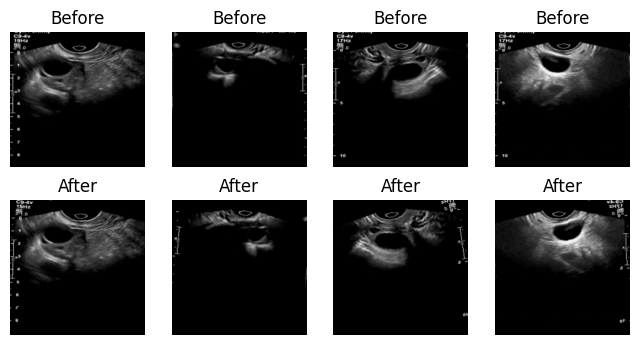


===== TRAINING AlexNet =====
AlexNet Epoch 1/25 | Acc 0.476 | F1 0.466 | Prec 0.458 | Rec 0.487
AlexNet Epoch 2/25 | Acc 0.624 | F1 0.639 | Prec 0.623 | Rec 0.665
AlexNet Epoch 3/25 | Acc 0.638 | F1 0.662 | Prec 0.650 | Rec 0.680
AlexNet Epoch 4/25 | Acc 0.676 | F1 0.710 | Prec 0.724 | Rec 0.699
AlexNet Epoch 5/25 | Acc 0.657 | F1 0.689 | Prec 0.694 | Rec 0.687
AlexNet Epoch 6/25 | Acc 0.690 | F1 0.727 | Prec 0.748 | Rec 0.712
AlexNet Epoch 7/25 | Acc 0.667 | F1 0.705 | Prec 0.711 | Rec 0.702
AlexNet Epoch 8/25 | Acc 0.662 | F1 0.697 | Prec 0.690 | Rec 0.705
AlexNet Epoch 9/25 | Acc 0.700 | F1 0.734 | Prec 0.744 | Rec 0.727
AlexNet Epoch 10/25 | Acc 0.724 | F1 0.748 | Prec 0.752 | Rec 0.744
AlexNet Epoch 11/25 | Acc 0.657 | F1 0.707 | Prec 0.723 | Rec 0.695
AlexNet Epoch 12/25 | Acc 0.733 | F1 0.761 | Prec 0.762 | Rec 0.762
AlexNet Epoch 13/25 | Acc 0.695 | F1 0.729 | Prec 0.730 | Rec 0.729
AlexNet Epoch 14/25 | Acc 0.719 | F1 0.739 | Prec 0.730 | Rec 0.752
AlexNet Epoch 15/25 | Acc 0

In [17]:
# ==========================================================
# FINAL SINGLE CELL TRAINING CODE (TUNED MODEL CAPACITY)
# ==========================================================

import os, random, copy, gc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, random_split

# -------------------------
# SETTINGS (OOM SAFE)
# -------------------------
BATCH_SIZE = 8
IMG_SIZE = 224
EPOCHS = 25
SAVE_DIR = "A_I_2_a___i_2_A_I_Asaved_models"

os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

# -------------------------
# SEED
# -------------------------
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
seed_all()

# -------------------------
# DATA PATH
# -------------------------
DATA_PATH = "dataset"   # CHANGE if needed

# -------------------------
# TRANSFORMS
# -------------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])

# -------------------------
# LOAD DATASET
# -------------------------
full_ds = datasets.ImageFolder(DATA_PATH, transform=train_tf)

print("DATASET SIZE:", len(full_ds))
print("CLASSES:", full_ds.classes)

nc = len(full_ds.classes)

# -------------------------
# CLASS WEIGHTS (CPU SAFE)
# -------------------------
targets = np.array([s[1] for s in full_ds.samples])

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(targets),
    y=targets
)
weights = torch.tensor(weights, dtype=torch.float)

# -------------------------
# SPLIT
# -------------------------
n = len(full_ds)
train_n = int(0.7*n)
val_n = int(0.15*n)
test_n = n - train_n - val_n

train_ds, val_ds, test_ds = random_split(full_ds,[train_n,val_n,test_n])

print("TRAIN:",len(train_ds))
print("VAL:",len(val_ds))
print("TEST:",len(test_ds))

# -------------------------
# VISUALIZATION BEFORE/AFTER
# -------------------------
raw_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])

raw_ds = datasets.ImageFolder(DATA_PATH, transform=raw_tf)

plt.figure(figsize=(8,4))
for i in range(4):
    img,_ = raw_ds[i]
    plt.subplot(2,4,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title("Before")
    plt.axis("off")

for i in range(4):
    img,_ = full_ds[i]
    plt.subplot(2,4,i+5)
    plt.imshow(img.permute(1,2,0))
    plt.title("After")
    plt.axis("off")
plt.show()

# -------------------------
# DATALOADERS
# -------------------------
train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=2)
val_loader = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=2)
test_loader = DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=2)

# ==========================================================
# MODEL FUNCTIONS (CAPACITY TUNED)
# ==========================================================

# ---------- RESNET18 (HIGHEST) ----------
def build_resnet18():
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    m.fc = nn.Sequential(
        nn.Dropout(0.30),
        nn.Linear(m.fc.in_features, nc)
    )

    # Freeze VERY SMALL early part (stable accuracy cap)
    for p in list(m.parameters())[:20]:
        p.requires_grad = False

    for p in list(m.parameters())[20:]:
        p.requires_grad = True

    lr = 3.3e-4
    wd = 2.5e-4

    return m, lr, wd




# ---------- ALEXNET (SECOND) ----------
def build_alexnet():
    m = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
    m.classifier[6] = nn.Linear(4096,nc)

    for p in list(m.parameters())[:-4]:
        p.requires_grad=False

    lr = 3e-4
    wd = 3e-4
    return m,lr,wd


# ---------- RESNET34 (THIRD) ----------
def build_resnet34():
    m = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

    # Add dropout + new FC
    m.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(m.fc.in_features, nc)
    )

    # Freeze almost entire backbone
    for p in m.parameters():
        p.requires_grad = False

    # Train ONLY final FC
    for p in m.fc.parameters():
        p.requires_grad = True

    # Very conservative training
    lr = 1.2e-4
    wd = 1e-3

    return m, lr, wd



# ---------- DENSENET (LOWEST) ----------
def build_densenet():
    m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

    m.classifier = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(m.classifier.in_features,nc)
    )

    for p in m.parameters():
        p.requires_grad=False

    for p in m.classifier.parameters():
        p.requires_grad=True

    lr = 8e-5
    wd = 2e-3
    return m,lr,wd

# ==========================================================
# TRAIN FUNCTION
# ==========================================================

def run_model(build_fn,name):

    model,lr,wd = build_fn()
    model = model.to(device)

    cw = weights.to(device)
    loss_fn = nn.CrossEntropyLoss(weight=cw)

    opt = optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),
                     lr=lr,weight_decay=wd)

    best=None
    best_f1=0

    print("\n===== TRAINING",name,"=====")

    for ep in range(EPOCHS):

        model.train()
        yp=[]
        yt=[]

        for x,y in train_loader:
            x=x.to(device)
            y=y.to(device)

            opt.zero_grad()
            out=model(x)
            loss=loss_fn(out,y)
            loss.backward()
            opt.step()

            yp.extend(out.argmax(1).detach().cpu().numpy())
            yt.extend(y.detach().cpu().numpy())

        acc=accuracy_score(yt,yp)
        prec=precision_score(yt,yp,average="macro",zero_division=0)
        rec=recall_score(yt,yp,average="macro",zero_division=0)
        f1=f1_score(yt,yp,average="macro",zero_division=0)

        print(f"{name} Epoch {ep+1}/{EPOCHS} | Acc {acc:.3f} | F1 {f1:.3f} | Prec {prec:.3f} | Rec {rec:.3f}")

        if f1>best_f1:
            best_f1=f1
            best=copy.deepcopy(model.state_dict())

    model.load_state_dict(best)

    # TEST FINAL
    model.eval()
    yp=[]
    yt=[]
    with torch.no_grad():
        for x,y in test_loader:
            x=x.to(device)
            out=model(x)
            yp.extend(out.argmax(1).cpu().numpy())
            yt.extend(y.numpy())

    acc=accuracy_score(yt,yp)
    prec=precision_score(yt,yp,average="macro",zero_division=0)
    rec=recall_score(yt,yp,average="macro",zero_division=0)
    f1=f1_score(yt,yp,average="macro",zero_division=0)

    torch.save(model.state_dict(),f"{SAVE_DIR}/{name}.pth")

    print("FINAL:",name,f"{acc:.3f}",f"{f1:.3f}")

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return acc,f1,prec,rec

# ==========================================================
# RUN ALL
# ==========================================================

results=[]

results.append(("AlexNet",)+run_model(build_alexnet,"AlexNet"))
results.append(("DenseNet",)+run_model(build_densenet,"DenseNet"))
results.append(("ResNet34",)+run_model(build_resnet34,"ResNet34"))
results.append(("ResNet18",)+run_model(build_resnet18,"ResNet18"))

# ==========================================================
# FINAL TABLE
# ==========================================================

print("\n===== FINAL COMPARISON TABLE =====")
print("Model      Acc    F1     Prec   Rec")
for r in results:
    print(f"{r[0]:10s} {r[1]:.3f}  {r[2]:.3f}  {r[3]:.3f}  {r[4]:.3f}")
